## GSAT trend patterns

In [1]:
# In[1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# %%
# define function
import src.SAT_function_Obs_Fingerprint as data_process
import src.Data_Preprocess as preprocess

In [2]:
# import src.slurm_cluster as scluster
# client, scluster = scluster.init_dask_slurm_cluster()

In [3]:
# Input the observational trend: original, forced and unforced
variable_name = ['1979-2022', '1993-2022']
dir_in = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG2/'
dir_in_forced_unforced = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIGS5_S6/cesm2_100/'

HadCRUT5_trend_original_da = {}
HadCRUT5_trend_forced_da = {}
HadCRUT5_trend_unforced_da = {}
for var in variable_name:
    print(var)
    HadCRUT5_trend_original_da[var] = xr.open_dataset(dir_in + 'Raw_HadCRUT5_MK_trend_1950-2022_sliding.nc').trend.sel(period=var)
    HadCRUT5_trend_forced_da[var] = xr.open_dataset(dir_in_forced_unforced + f'trend_forced_HadCRUT5_annual/' +'forced_HadCRUT5_MMLE_MK_trend_1950-2022_sliding.nc').trend.sel(period=var)
    HadCRUT5_trend_unforced_da[var] = xr.open_dataset(dir_in_forced_unforced +f'trend_ICV_HadCRUT5_annual/' + 'ICV_HadCRUT5_MMLE_MK_trend_1950-2022_sliding.nc').trend.sel(period=var)
    
HadCRUT5_pvalue_original_da = {}
HadCRUT5_pvalue_forced_da = {}
HadCRUT5_pvalue_unforced_da = {}
for var in variable_name:
    HadCRUT5_pvalue_original_da[var] = xr.open_dataset(dir_in + 'Raw_HadCRUT5_MK_trend_1950-2022_sliding.nc').p_value.sel(period=var)
    HadCRUT5_pvalue_forced_da[var] = xr.open_dataset(dir_in_forced_unforced + f'trend_forced_HadCRUT5_annual/' +'forced_HadCRUT5_MMLE_MK_trend_1950-2022_sliding.nc').p_value.sel(period=var)
    HadCRUT5_pvalue_unforced_da[var] = xr.open_dataset(dir_in_forced_unforced +f'trend_ICV_HadCRUT5_annual/' + 'ICV_HadCRUT5_MMLE_MK_trend_1950-2022_sliding.nc').p_value.sel(period=var)
    

1979-2022
1993-2022


In [4]:
HadCRUT5_pvalue_forced_da

{'1979-2022': <xarray.DataArray 'p_value' (lat: 90, lon: 180)>
 [16200 values with dtype=float64]
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
     period   <U9 '1979-2022',
 '1993-2022': <xarray.DataArray 'p_value' (lat: 90, lon: 180)>
 [16200 values with dtype=float64]
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
     period   <U9 '1993-2022'}

In [5]:
HadCRUT5_trend_original_da

{'1979-2022': <xarray.DataArray 'trend' (lat: 90, lon: 180)>
 [16200 values with dtype=float64]
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
     period   <U9 '1979-2022',
 '1993-2022': <xarray.DataArray 'trend' (lat: 90, lon: 180)>
 [16200 values with dtype=float64]
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
     period   <U9 '1993-2022'}

In [6]:
HadCRUT5_pvalue_forced_da

{'1979-2022': <xarray.DataArray 'p_value' (lat: 90, lon: 180)>
 [16200 values with dtype=float64]
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
     period   <U9 '1979-2022',
 '1993-2022': <xarray.DataArray 'p_value' (lat: 90, lon: 180)>
 [16200 values with dtype=float64]
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
     period   <U9 '1993-2022'}

### Plotting with the Robinson Projections

In [7]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colors import BoundaryNorm
import cartopy.util as cutil
import seaborn as sns
import matplotlib.colors as mcolors
import palettable
#  cmap = mcolors.ListedColormap(palettable.scientific.diverging.Vik_20.mpl_colors)
cmap=mcolors.ListedColormap(palettable.cmocean.diverging.Balance_20.mpl_colors)

In [8]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mticker
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import seaborn as sns

def plot_trend_with_significance(trend_data, lats, lons, p_values, GMST_p_values=None, levels=None, extend=None, cmap=None, 
                                 title="", ax=None, show_xticks=False, show_yticks=False):
    """
    Plot the trend spatial pattern using Robinson projection with significance overlaid.

    Parameters:
    - trend_data: 2D numpy array with the trend values.
    - lats, lons: 1D arrays of latitudes and longitudes.
    - p_values: 2D array with p-values for each grid point.
    - GMST_p_values: 2D array with GMST p-values for each grid point.
    - title: Title for the plot.
    - ax: Existing axis to plot on. If None, a new axis will be created.
    - show_xticks, show_yticks: Boolean flags to show x and y axis ticks.
    
    Returns:
    - contour_obj: The contour object from the plot.
    """

    # Create a new figure/axis if none is provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(15, 25), subplot_kw={'projection': ccrs.Robinson()})
        ax.set_global()
  
    # Determine significance mask (where p-values are less than 0.05)
    insignificance_mask = p_values >= 0.05
    # Plotting
    # contour_obj = ax.pcolormesh(lons, lats, trend_data,  cmap='RdBu_r',vmin=-5.0, vmax=5.0, transform=ccrs.PlateCarree(central_longitude=180), shading='auto')
    contour_obj = ax.contourf(lons, lats, trend_data, levels=levels, extend=extend, cmap=cmap, transform=ccrs.PlateCarree(central_longitude=0))

    # Plot significance masks with different hatches
    ax.contourf(lons, lats, insignificance_mask, levels=[0, 0.05, 1.0],hatches=[None,'///'], colors='none', transform=ccrs.PlateCarree())

    ax.coastlines(resolution='110m')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                      color='gray', alpha=0.15, linestyle='--', linewidth=0.25)

    # Disable labels on the top and right of the plot
    gl.top_labels = False
    gl.right_labels = False

    # Enable labels on the bottom and left of the plot
    gl.bottom_labels = show_xticks
    gl.left_labels = show_yticks
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()
    gl.xlabel_style = {'size': 16}
    gl.ylabel_style = {'size': 16}
    
    if show_xticks:
        gl.bottom_labels = True
    if show_yticks:
        gl.left_labels = True
    
    ax.set_title(title, loc='center', fontname='Myriad Pro', fontsize=20, pad=5.0)

    return contour_obj


In [9]:
def plot_trend(trend_data, lats, lons, levels=None, extend=None, cmap=None, 
                                 title="", ax=None, show_xticks=False, show_yticks=False):
    """
    Plot the trend spatial pattern using Robinson projection with significance overlaid.

    Parameters:
    - trend_data: 2D numpy array with the trend values.
    - lats, lons: 1D arrays of latitudes and longitudes.
    - p_values: 2D array with p-values for each grid point.
    - GMST_p_values: 2D array with GMST p-values for each grid point.
    - title: Title for the plot.
    - ax: Existing axis to plot on. If None, a new axis will be created.
    - show_xticks, show_yticks: Boolean flags to show x and y axis ticks.
    
    Returns:
    - contour_obj: The contour object from the plot.
    """

    # Create a new figure/axis if none is provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(15, 25), subplot_kw={'projection': ccrs.Robinson()})
        ax.set_global()
  
    # Plotting
    # contour_obj = ax.pcolormesh(lons, lats, trend_data,  cmap='RdBu_r',vmin=-5.0, vmax=5.0, transform=ccrs.PlateCarree(central_longitude=180), shading='auto')
    contour_obj = ax.contourf(lons, lats, trend_data, levels=levels, extend=extend, cmap=cmap, transform=ccrs.PlateCarree(central_longitude=0))

    ax.coastlines(resolution='110m')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                      color='gray', alpha=0.15, linestyle='--', linewidth=0.25)

    # Disable labels on the top and right of the plot
    gl.top_labels = False
    gl.right_labels = False

    # Enable labels on the bottom and left of the plot
    gl.bottom_labels = show_xticks
    gl.left_labels = show_yticks
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()
    gl.xlabel_style = {'size': 16}
    gl.ylabel_style = {'size': 16}
    
    if show_xticks:
        gl.bottom_labels = True
    if show_yticks:
        gl.left_labels = True
    
    ax.set_title(title, loc='center', fontname='Myriad Pro', fontsize=20, pad=5.0)

    return contour_obj

### Plot the Original, Forced, MMEM trend patterns

In [10]:
# input MMLE trend Forced and Unforced
dir_diff = '/work/mh0033/m301036/OBS_LPS_revision/script/FIG3/Pattern_diff/MMLE_OBS_forced_pattern_diff_1950_2022.nc'
da_forced_trend = xr.open_dataset(dir_diff).trend_diff.sel(period='1979-2022')

dir_diff_ICV = '/work/mh0033/m301036/OBS_LPS_revision/script/FIG3/Pattern_diff/MMLE_OBS_ICV_pattern_diff_1950_2022.nc'
da_ICV_trend = xr.open_dataset(dir_diff_ICV).ICV_trend_std_diff.sel(period='1979-2022')

In [11]:
# define an asymmetric colormap
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colors import BoundaryNorm
import cartopy.util as cutil
import seaborn as sns
import matplotlib.colors as mcolors
import palettable


In [12]:
# put all the trend and p-value into a dictionary for easy plotting
trend_1979_2022 = {
    'HadCRUT5 Raw': HadCRUT5_trend_original_da['1979-2022'],
    'Forced wrt. MMEM': HadCRUT5_trend_forced_da['1979-2022'],
    'Unforced wrt. MMEM': HadCRUT5_trend_unforced_da['1979-2022']
}
p_value_1979_2022 = {
    'HadCRUT5 Raw': HadCRUT5_pvalue_original_da['1979-2022'],
    'Forced wrt. MMEM': HadCRUT5_pvalue_forced_da['1979-2022'],
    'Unforced wrt. MMEM': HadCRUT5_pvalue_unforced_da['1979-2022']
}
trend_30yr = {
    'HadCRUT5 Raw': HadCRUT5_trend_original_da['1993-2022'],
    'Forced wrt. MMEM': HadCRUT5_trend_forced_da['1993-2022'],
    'Unforced wrt. MMEM': HadCRUT5_trend_unforced_da['1993-2022']
}
p_value_30yr = {
    'HadCRUT5 Raw': HadCRUT5_pvalue_original_da['1993-2022'],
    'Forced wrt. MMEM': HadCRUT5_pvalue_forced_da['1993-2022'],
    'Unforced wrt. MMEM': HadCRUT5_pvalue_unforced_da['1993-2022']
}

In [13]:
trend_1979_2022

{'HadCRUT5 Raw': <xarray.DataArray 'trend' (lat: 90, lon: 180)>
 [16200 values with dtype=float64]
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
     period   <U9 '1979-2022',
 'Forced wrt. MMEM': <xarray.DataArray 'trend' (lat: 90, lon: 180)>
 [16200 values with dtype=float64]
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
     period   <U9 '1979-2022',
 'Unforced wrt. MMEM': <xarray.DataArray 'trend' (lat: 90, lon: 180)>
 [16200 values with dtype=float64]
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
     period   <U9 '1979-2022'}

In [14]:
# Plotting
"""
first column: original trend and p-value
second column: forced trend and p-value
third column: unforced trend and p-value
each row is a different time period
"""
lat = trend_1979_2022['HadCRUT5 Raw'].lat
lon = trend_1979_2022['HadCRUT5 Raw'].lon
lat, lon 

(<xarray.DataArray 'lat' (lat: 90)>
 array([-89., -87., -85., -83., -81., -79., -77., -75., -73., -71., -69., -67.,
        -65., -63., -61., -59., -57., -55., -53., -51., -49., -47., -45., -43.,
        -41., -39., -37., -35., -33., -31., -29., -27., -25., -23., -21., -19.,
        -17., -15., -13., -11.,  -9.,  -7.,  -5.,  -3.,  -1.,   1.,   3.,   5.,
          7.,   9.,  11.,  13.,  15.,  17.,  19.,  21.,  23.,  25.,  27.,  29.,
         31.,  33.,  35.,  37.,  39.,  41.,  43.,  45.,  47.,  49.,  51.,  53.,
         55.,  57.,  59.,  61.,  63.,  65.,  67.,  69.,  71.,  73.,  75.,  77.,
         79.,  81.,  83.,  85.,  87.,  89.])
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
     period   <U9 '1979-2022'
 Attributes:
     standard_name:  latitude
     long_name:      latitude
     units:          degrees_north
     axis:           Y,
 <xarray.DataArray 'lon' (lon: 180)>
 array([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  1

In [15]:
from src.plot_func import *
set_science_advances_style()

In [16]:
plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams["font.family"] = "Times New Roman"
plt.rc('font', family='serif')

In [17]:
import matplotlib.font_manager as fm
plt.rcParams['figure.figsize'] = (8, 10)
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['ytick.major.right'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.1
plt.rcParams['savefig.transparent'] = True
plt.rcParams['pdf.fonttype'] = 42
# Prefer Myriad Pro if installed; fall back to DejaVu Sans.
try:
    plt.rcParams['font.sans-serif'] = ['Myriad Pro', 'Myriad', 'DejaVu Sans']
except:
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "Helvetica"
# })

In [18]:
trend_1979_2022['Forced wrt. MMEM']

<xarray.DataArray 'trend' (lat: 90, lon: 180)>
[16200 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
    period   <U9 '1979-2022'

In [19]:
from scipy.stats import pearsonr
import xarray as xr
import numpy as np

# --- helper: compute r and RMSE for a given variable name ---
def corr_rmse_between_periods(da_1979_2022, da_30yr, var_name):
    # select the two periods as 2D fields (lat, lon) and drop scalar period coords
    x = da_1979_2022[var_name].squeeze(drop=True).reset_coords("period", drop=True)
    y = da_30yr[var_name].squeeze(drop=True).reset_coords("period", drop=True)

    # align in case of any subtle coord differences; ignore conflicts on scalar coords
    x, y = xr.align(x, y, join="inner")

    # lat as DataArray (for weights)
    lat_da = x["lat"]

    # Pearson correlation on flattened fields
    r, _ = pearsonr(x.values.ravel(), y.values.ravel())

    # Area-weighted RMSE computed directly to avoid compat issues
    weights_1d = np.cos(np.deg2rad(lat_da))
    weights = weights_1d.broadcast_like(x)
    mse = ((x - y) ** 2 * weights).sum(dim=("lat", "lon")) / weights.sum(dim=("lat", "lon"))
    rmse = float(np.sqrt(mse))

    return r, rmse

# ----- forced -----
p_corr_forced, rmse_forced = corr_rmse_between_periods(trend_1979_2022, trend_30yr, "Forced wrt. MMEM")

# ----- raw -----
p_corr_raw, rmse_raw = corr_rmse_between_periods(trend_1979_2022, trend_30yr, "HadCRUT5 Raw")

# ----- unforced -----
p_corr_unforced, rmse_unforced = corr_rmse_between_periods(trend_1979_2022, trend_30yr, "Unforced wrt. MMEM")

print(f"Forced:    r = {p_corr_forced:.3f}, RMSE = {rmse_forced:.3f}")
print(f"Raw:       r = {p_corr_raw:.3f},    RMSE = {rmse_raw:.3f}")
print(f"Unforced:  r = {p_corr_unforced:.3f}, RMSE = {rmse_unforced:.3f}")

Forced:    r = 1.000, RMSE = 0.023
Raw:       r = 0.939,    RMSE = 0.082
Unforced:  r = 0.818, RMSE = 0.085


In [ ]:
# titles =["Raw Trend",  "Forced Trend"+ r'$_{wrt.MMEM} $', 
#     "Unforced Trend"+ r'$_{wrt.MMEM} $']
titles =["Total",  "External forcing", "Internal variability"]
titles_rows = ["Satellite era\n(1979-2022)","30-year\n(1993-2022)"]
titles_left_corner = ["A", "B", "C", "D", "E", "F"]

variable_name = ["HadCRUT5 Raw", "Forced wrt. MMEM", "Unforced wrt. MMEM"]
intervals = np.arange(-1.0, 1.1, 0.1)

fig = plt.figure(figsize=(20, 8))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 1], wspace=0.05, hspace=0.2)

extend='both'
axes = {}
for i, var in enumerate(variable_name):
    is_left = i == 0
    is_bottom_row = False
        
    ax = plt.subplot(gs[i], projection=ccrs.Robinson(180))
    ax.set_global()
    axes[i] = ax
    
    trend_data = trend_1979_2022[var]
    p_values = p_value_1979_2022[var]
    trend_with_cyclic, lons_cyclic = cutil.add_cyclic_point(trend_data, coord=lon)
    p_values_with_cyclic, lons_cyclic = cutil.add_cyclic_point(p_values, coord=lon)
            
    contour_obj = plot_trend_with_significance(trend_with_cyclic, lat, lons_cyclic, p_values_with_cyclic, 
                                                levels=intervals, extend=extend, cmap='RdBu_r', 
                                                title=" ", ax=ax, show_xticks=is_bottom_row, show_yticks=is_left)
    
    # Add title and letter label
    ax.text(0.5, 1.08, titles[i], va='bottom', ha='center', fontsize=20, transform=ax.transAxes)
    ax.text(-0.05, 1.05, titles_left_corner[i], va='top', ha='left', weight='bold', fontsize=20, transform=ax.transAxes)
    # plot the 1993-2022 row
for i, var in enumerate(variable_name):
    is_left = i == 0
    is_bottom_row = True if i < 1 else False
        
    ax = plt.subplot(gs[i+3], projection=ccrs.Robinson(180))
    ax.set_global()
    axes[i+3] = ax
    
    trend_data = trend_30yr[var]
    p_values = p_value_30yr[var]
    trend_with_cyclic, lons_cyclic = cutil.add_cyclic_point(trend_data, coord=lon)
    p_values_with_cyclic, lons_cyclic = cutil.add_cyclic_point(p_values, coord=lon)
            
    contour_obj1 = plot_trend_with_significance(trend_with_cyclic, lat, lons_cyclic, p_values_with_cyclic, 
                                                levels=intervals, extend=extend, cmap='RdBu_r', 
                                                title=" ", ax=ax, show_xticks="True", show_yticks=is_left)
    
    # Add title and letter label
    # ax.text(0.5, 1.08, titles[i], va='bottom', ha='center', fontsize=20, transform=ax.transAxes)
    ax.text(-0.05, 1.05, titles_left_corner[i+3], va='top', ha='left', weight='bold', fontsize=20, transform=ax.transAxes)  
# Add row label on the left
axes[0].text(-0.25, 0.5, titles_rows[0], va='center', ha='center', rotation=90, fontsize=20, transform=axes[0].transAxes)
axes[3].text(-0.25, 0.5, titles_rows[1], va='center', ha='center', rotation=90, fontsize=20, transform=axes[3].transAxes)
# Add pattern correlation and RMSE annotations to the second row (30-year)
corr_vals = [p_corr_raw, p_corr_forced, p_corr_unforced]
rmse_vals = [rmse_raw, rmse_forced, rmse_unforced]

for idx, (corr, rmse_val) in enumerate(zip(corr_vals, rmse_vals)):
    ax = axes[idx + 3]  # axes 3,4,5 correspond to the second row
    ax.text(0.05, 1.02, f"P_corr = {corr:.3f}", va="bottom", ha="left", fontsize=16, transform=ax.transAxes)
    ax.text(0.55, 1.02, f"RMSE = {rmse_val:.3f}", va="bottom", ha="left", fontsize=16, transform=ax.transAxes)

# Add colorbar
cbar_ax = fig.add_axes([0.2, 0.01, 0.6, 0.05])
cbar = fig.colorbar(contour_obj1, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=18)
cbar.set_label('SAT trend (°C per decade)', fontsize=20)
cbar.ax.tick_params(direction='out', length=8, width=2)  
cbar.ax.minorticks_off()

figure_output = '/work/mh0033/m301036/OBS_LPS_revision/docs/Figs/FIG_Satellite/'
for ext in ("png", "pdf"):
    fig.savefig(figure_output+f"FIGURE_S7_Satellite_OBS_trend_partition.{ext}", dpi=300, bbox_inches='tight')

plt.show()

/tmp/ipykernel_46963/3010791737.py:63: MatplotlibDeprecationWarning: The 'extend' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar1 = fig.colorbar(contour_obj_raw, cax=cbar_ax1, orientation='horizontal', extend=extend)
/tmp/ipykernel_46963/3010791737.py:71: MatplotlibDeprecationWarning: The 'extend' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar2 = fig.colorbar(contour_obj_forced, cax=cbar_ax2, orientation='horizontal', extend=extend)
findfont: Font family ['Myriad Pro'] not found. Falling back to DejaVu Sans.


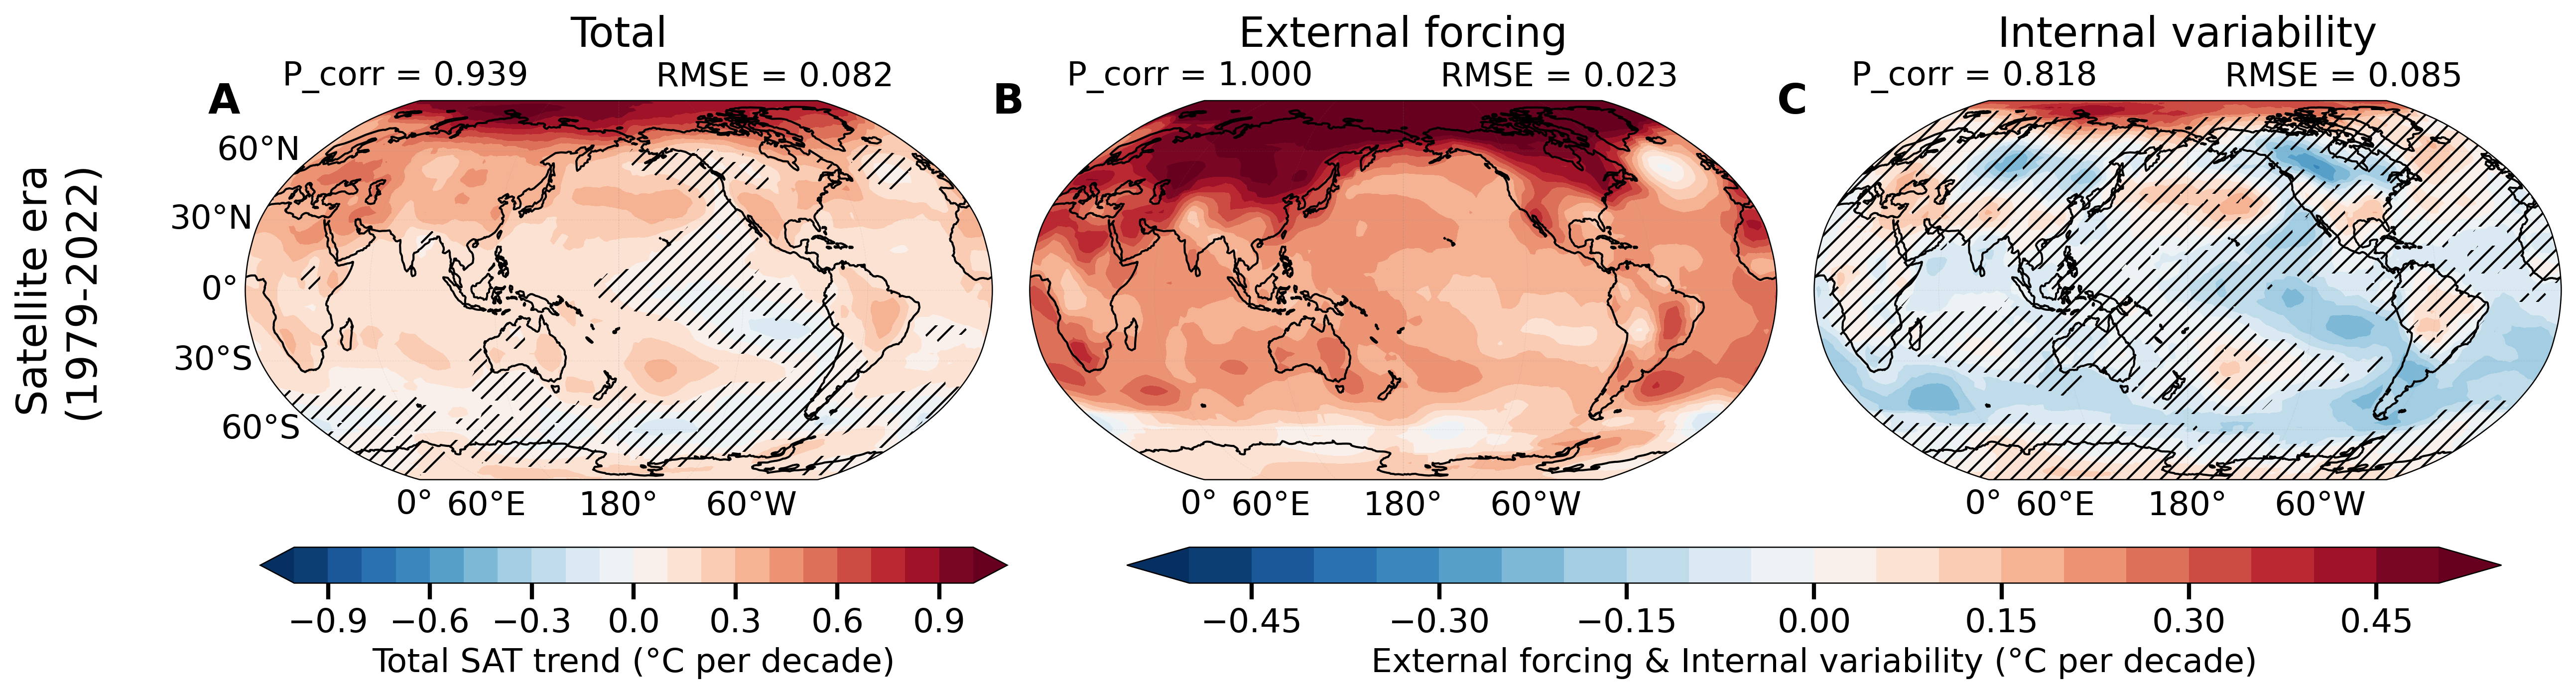

In [20]:
# titles =["Raw Trend",  "Forced Trend"+ r'$_{wrt.MMEM} $', 
#     "Unforced Trend"+ r'$_{wrt.MMEM} $']
titles =["Total",  "External forcing", "Internal variability"]
titles_rows = ["Satellite era\n(1979-2022)","30-year\n(1993-2022)"]
titles_left_corner = ["A", "B", "C"]

variable_name = ["HadCRUT5 Raw", "Forced wrt. MMEM", "Unforced wrt. MMEM"]
# Set up intervals for different variables
intervals_raw = np.arange(-1.0, 1.1, 0.1)
intervals = np.arange(-0.5, 0.55, 0.05)

fig = plt.figure(figsize=(20, 8))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=0.05, hspace=0.2)

extend='both'
axes = {}
contour_obj_raw = None  # For first column colorbar
contour_obj_forced = None  # For second/third column colorbar

for i, var in enumerate(variable_name):
    is_left = i == 0
    is_bottom_row = True
        
    ax = plt.subplot(gs[i], projection=ccrs.Robinson(180))
    ax.set_global()
    axes[i] = ax
    
    trend_data = trend_1979_2022[var]
    p_values = p_value_1979_2022[var]
    trend_with_cyclic, lons_cyclic = cutil.add_cyclic_point(trend_data, coord=lon)
    p_values_with_cyclic, lons_cyclic = cutil.add_cyclic_point(p_values, coord=lon)
    # First column uses intervals_raw, others use intervals
    if i == 0:
        current_levels = intervals_raw
    else:
        current_levels = intervals
    contour_obj = plot_trend_with_significance(trend_with_cyclic, lat, lons_cyclic, p_values_with_cyclic, 
                                                levels=current_levels, extend=extend, cmap='RdBu_r', 
                                                title=" ", ax=ax, show_xticks=is_bottom_row, show_yticks=is_left)
     # Store contour objects for colorbars
    if i == 0 and contour_obj_raw is None:
            contour_obj_raw = contour_obj
    elif i > 0 and contour_obj_forced is None:
            contour_obj_forced = contour_obj
    # Add title and letter label
    ax.text(0.5, 1.12, titles[i], va='bottom', ha='center', fontsize=20, transform=ax.transAxes)
    ax.text(-0.05, 1.05, titles_left_corner[i], va='top', ha='left', weight='bold', fontsize=20, transform=ax.transAxes)
    # plot the 1993-2022 row
# Add row label on the left
axes[0].text(-0.25, 0.5, titles_rows[0], va='center', ha='center', rotation=90, fontsize=20, transform=axes[0].transAxes)
# axes[3].text(-0.25, 0.5, titles_rows[1], va='center', ha='center', rotation=90, fontsize=20, transform=axes[3].transAxes)
# Add pattern correlation and RMSE annotations to the second row (30-year)
corr_vals = [p_corr_raw, p_corr_forced, p_corr_unforced]
rmse_vals = [rmse_raw, rmse_forced, rmse_unforced]

for idx, (corr, rmse_val) in enumerate(zip(corr_vals, rmse_vals)):
    ax = axes[idx]  # axes 3,4,5 correspond to the second row
    ax.text(0.05, 1.02, f"P_corr = {corr:.3f}", va="bottom", ha="left", fontsize=16, transform=ax.transAxes)
    ax.text(0.55, 1.02, f"RMSE = {rmse_val:.3f}", va="bottom", ha="left", fontsize=16, transform=ax.transAxes)

# Add colorbar
cbar_ax1 = fig.add_axes([0.13, 0.25, 0.25, 0.03])
cbar1 = fig.colorbar(contour_obj_raw, cax=cbar_ax1, orientation='horizontal', extend=extend)
cbar1.ax.tick_params(labelsize=16)
cbar1.set_label('Total SAT trend (°C per decade)', fontsize=16)
cbar1.ax.tick_params(direction='out', length=8, width=2)
cbar1.ax.minorticks_off()

# Colorbar for second and third columns (forced/unforced with smaller range)
cbar_ax2 = fig.add_axes([0.42, 0.25, 0.46, 0.03])
cbar2 = fig.colorbar(contour_obj_forced, cax=cbar_ax2, orientation='horizontal', extend=extend)
cbar2.ax.tick_params(labelsize=16)
cbar2.set_label('External forcing & Internal variability (°C per decade)', fontsize=16)
cbar2.ax.tick_params(direction='out', length=8, width=2)
cbar2.ax.minorticks_off()

figure_output = '/work/mh0033/m301036/OBS_LPS_revision/docs/Figs/FIG_Satellite/'
for ext in ("png", "pdf"):
    fig.savefig(figure_output+f"FIGURE_S5_Satellite_OBS_trend_partition.{ext}", dpi=300, bbox_inches='tight')

plt.show()